# P1: Import of the data

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import glob
import os
import seaborn as sns
import tensorflow as tf
import cv2
from tensorflow.python.client import device_lib

from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam

In [4]:
import keras
print(keras.__version__)

3.14.1


In [12]:
# Source - https://stackoverflow.com/a/67504607
# Posted by Briar Campbell, modified by community. See post 'Timeline' for change history
# Retrieved 2026-05-27, License - CC BY-SA 4.0
# Check for Nvidia GPU

import subprocess

try:
    subprocess.check_output('nvidia-smi')
    print('Nvidia GPU detected\n')
    print(pd.DataFrame(subprocess.check_output('nvidia-smi').decode('utf-8').split('\n')))
except (subprocess.CalledProcessError, FileNotFoundError):
    print('No Nvidia GPU in system')
except Exception as e:
    print(f'An unexpected error occurred: {e}')

Nvidia GPU detected

                                                    0
0                     Wed May 27 15:50:14 2026       
1   +---------------------------------------------...
2   | NVIDIA-SMI 595.71.05              Driver Ver...
3   +-----------------------------------------+---...
4   | GPU  Name                 Persistence-M | Bu...
5   | Fan  Temp   Perf          Pwr:Usage/Cap |   ...
6   |                                         |   ...
7   |=========================================+===...
8   |   0  NVIDIA GeForce RTX 3060        Off |   ...
9   |  0%   55C    P8             22W /  170W |   ...
10  |                                         |   ...
11  +-----------------------------------------+---...
12                                                   
13  +---------------------------------------------...
14  | Processes:                                  ...
15  |  GPU   GI   CI              PID   Type   Pro...
16  |        ID   ID                              ...
17  |==

In [13]:
def evaluate_metric(y_true, y_pred, class_names):
    
    cm = confusion_matrix(y_true, y_pred)
    
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)

    # Affichage de la matrice de confusion
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', 
                xticklabels=class_names, 
                yticklabels=class_names)
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.title('Confusion Matrix')
    plt.show()

    metrics = {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    }
    return metrics

In [14]:
train_dataset_main = "../data/train"
test_dataset_main = "../data/test"
valid_dataset_main = "..//data/valid"

In [15]:
# Tiryaki, S. (s.d.). Facial Expressions Classification. 
# Link: https://www.kaggle.com/code/sahintiryaki/facial-expressions-classification
def create_dataset_df(main_path, dataset_name):
    print(f"{dataset_name} is creating ...")
    df = {"img_path":[],"class_names":[]}
    for class_names in os.listdir(main_path):
        # Select only the emotions we want to detect.
        if class_names in {"happy", "angry", "neutral", "sad", "surprise"}:
            for img_path in glob.glob(f"{main_path}/{class_names}/*"):
                df["img_path"].append(img_path)
                df["class_names"].append(class_names)
    df = pd.DataFrame(df)
    print(f"{dataset_name} is created !")
    return df

In [16]:
train_df = create_dataset_df(train_dataset_main, "Train dataset")
train_df.size

Train dataset is creating ...
Train dataset is created !


169756

In [17]:
test_df = create_dataset_df(test_dataset_main, "Test dataset")
test_df.size

Test dataset is creating ...
Test dataset is created !


32020

In [18]:
valid_df = create_dataset_df(valid_dataset_main, "Valid dataset")
valid_df.size

Valid dataset is creating ...
Valid dataset is created !


32082

In [19]:
train_df.head()

,img_path,class_names
0,../data/train/happy/80288Exp3awe_grandmother_1...,happy
1,../data/train/happy/65014Exp3astound_worker_96...,happy
2,../data/train/happy/53132Exp3amazed_African_61...,happy
3,../data/train/happy/Happy.2985.jpg,happy
4,../data/train/happy/70972Exp3awe_student_343.jpg,happy


In [20]:
def vizualizing_images(df,n_rows,n_cols):
    plt.figure(figsize=(10,10))
    for i in range(n_rows*n_cols):
        index = np.random.randint(0, len(df))
        img = cv2.imread(df.img_path[index])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        class_nm = df.class_names[index]
        plt.subplot(n_rows, n_cols, i+1)
        plt.imshow(img, plt.cm.gray)
        plt.title(class_nm)
    plt.show()

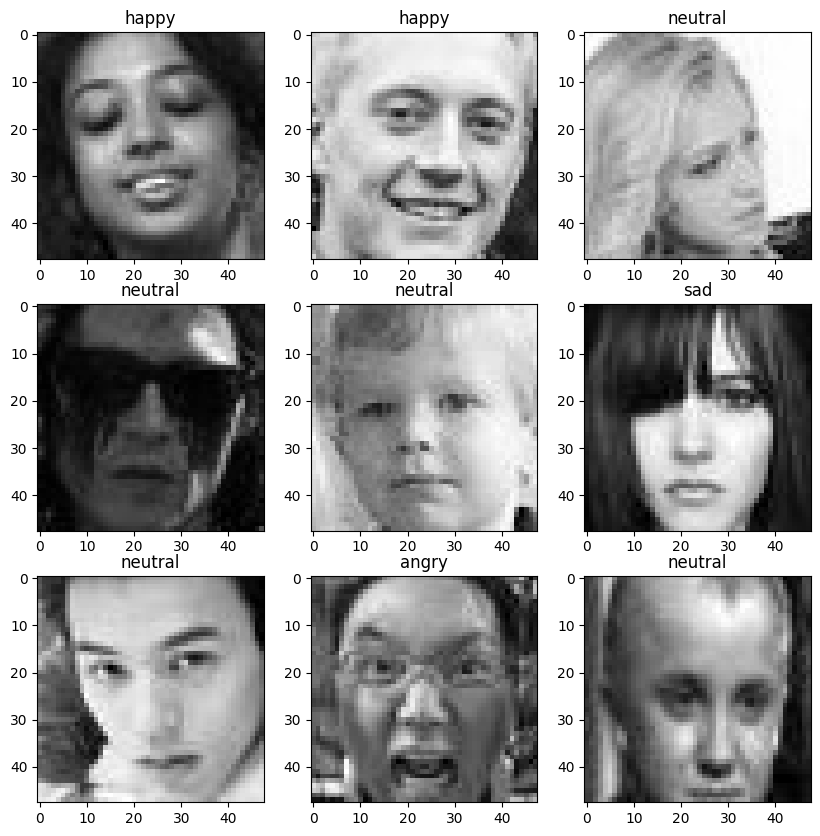

In [21]:
vizualizing_images(train_df, 3, 3)

# P2: Build the CNN (ResNet)

In [22]:
#https://github.com/tensorflow/tpu/tree/master/models/official/efficientnet

In [ ]:
import tensorflow as tf
print(tf.config.list_physical_devices())

In [ ]:
BATCH_SIZE = 64
EPOCHS = 40
IMG_CHANNEL = 3
IMG_W, IMG_H = 150, 150

In [ ]:
# EfficientNet BO as a model
B_model = keras.applications.EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_W, IMG_H, 3),
)

In [ ]:
B_model.trainable = False

In [ ]:
inputs = keras.Input(shape=(IMG_W, IMG_H, 3))

x = B_model(inputs, training=False)
x = keras.layers.GlobalAveragePooling2D()(x)
x = keras.layers.Dropout(0.5)(x)
x = keras.layers.Dense(128, activation="relu")(x)
x = keras.layers.Dropout(0.3)(x)
outputs = keras.layers.Dense(5, activation="softmax")(x)

model = keras.Model(inputs=inputs, outputs=outputs, name="efficientnet_emotion")

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
model.summary()

In [ ]:
# Entrainement
train_datagen = ImageDataGenerator(
    rescale = 1/.255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='img_path',
    y_col='class_names',
    target_size=(150, 150),
    batch_size=64,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='img_path',
    y_col='class_names',
    target_size=(IMG_W, IMG_H),
    batch_size=64,
    class_mode='categorical',
    shuffle=False
)

early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    train_generator,
    epochs=40,
    validation_data=valid_generator,
    callbacks=[early_stopping]
)

In [ ]:
EMOTIONS = ['angry', 'happy', 'neutral', 'sad', 'surprise']

y_pred = model.predict(test_generator)
y_pred_classes = y_pred.argmax(axis=1)
y_true = test_generator.classes

evaluate_metric(y_true, y_pred_classes, EMOTIONS)

In [ ]:
valid_generator = train_datagen.flow_from_dataframe(
    dataframe = valid_df,
    x_col = 'img_path',
    y_col = 'class_names',
    target_size=(IMG_W, IMG_H),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)